# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_goldfeldquandt, het_white


# Functions for automation

In [2]:
def distribution_plot(df_column):
    fig, axs = plt.subplots(1, 2, figsize = (12, 8))
    fig.suptitle(f'Distribution analysis')

    sns.histplot(df_column, ax = axs[0])
    axs[0].set_title('Histogram')

    stats.probplot(df_column, dist = "norm", plot = axs[1])
    axs[1].set_title('Probability Plot')

    plt.tight_layout(rect = [0, 0, 1, 0.95])
    plt.show()

# Data Loading

In [3]:
cars_df = pd.read_csv('cars.csv')
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


In [4]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [5]:
print("Кількість числових стовпців:", len(cars_df.select_dtypes("number").columns))
print("Кількість стовпців типу рядок:", len(cars_df.select_dtypes(exclude = "number").columns))

Кількість числових стовпців: 8
Кількість стовпців типу рядок: 5


The dataset contains 100 observations and 13 columns. There are no gaps in the data, which is good.

In the dataset, we have 8 numeric and 5 row columns that can reflect certain categorical data.

Let's analyze the obtained features and the studied variable in more detail.

Let's immediately note that Car_ID -- the car ad identifier will not be considered in the analysis and modeling, since it is only a serial number for identifying the ad, but it does not affect the determination of the car's value.

## Exploratory data analysis

### Price

First, let's look at the modeled variable -- Price

In [6]:
cars_df['Price'].describe(percentiles=[0.99, 0.999])

count    1.000000e+02
mean     1.574000e+06
std      1.000265e+06
min      4.500000e+05
50%      1.300000e+06
99%      4.000000e+06
99.9%    4.000000e+06
max      4.000000e+06
Name: Price, dtype: float64

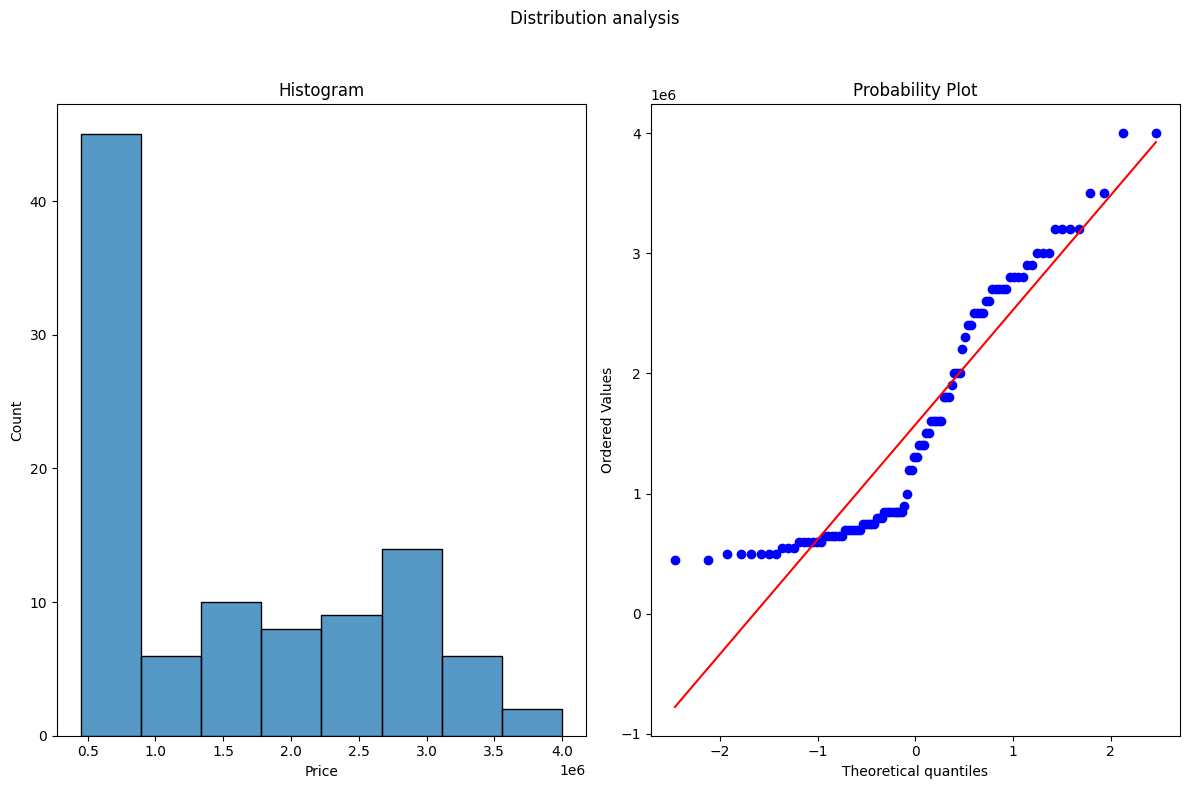

In [7]:
distribution_plot(cars_df['Price'])

In [8]:
fig = px.histogram(cars_df,
                   x = 'Price',
                   marginal = 'box',
                   nbins = 20,
                   title = 'Distribution of Price'

)

fig.update_layout(bargap = 0.1)
fig.show()

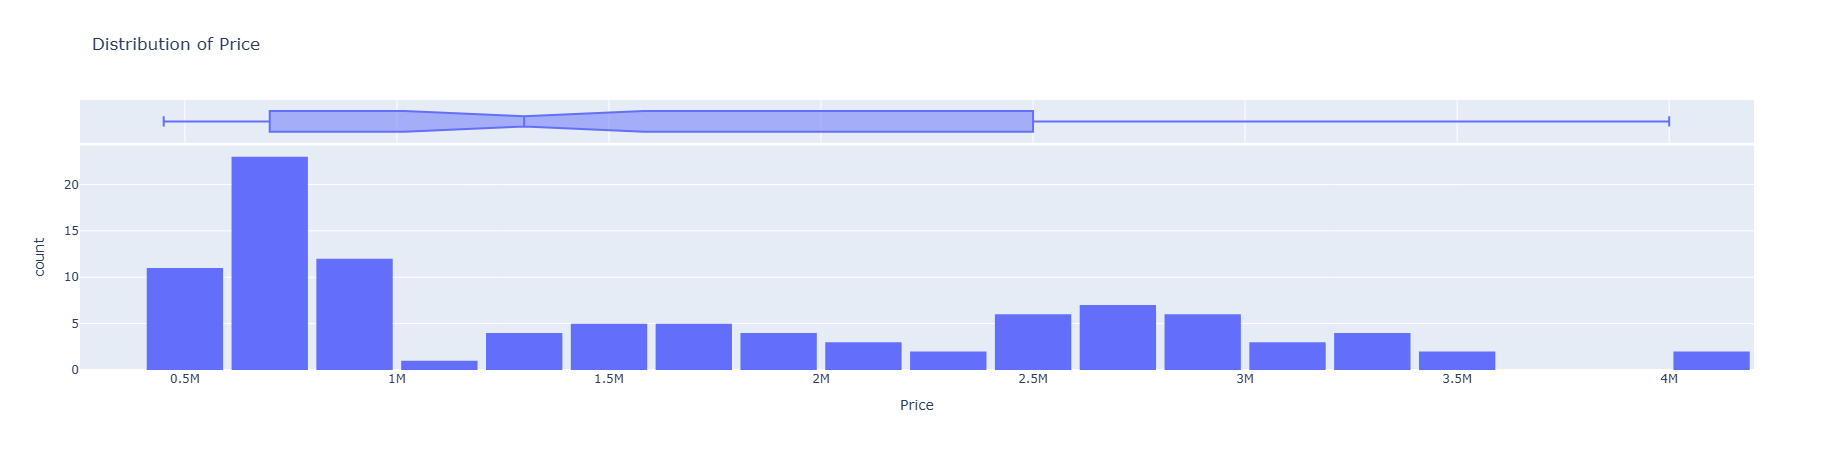

The cost of a car is not normally distributed, but is represented by a right-skewed distribution, which is reflected in the excess of the mean over the median. The lack of a normal distribution is also confirmed by the QQ plot. There are no outliers in the data.

- Minimum cost of a car: 700k INR
- Maximum cost: 2.5M INR
- Average cost: 1.574M INR
- Median cost: 1.3M INR

### Kilometers_Driven

In [9]:
cars_df['Kilometers_Driven'].describe(percentiles=[0.99, 0.999])

count      100.000000
mean     28150.000000
std       9121.375716
min      10000.000000
50%      27000.000000
99%      50100.000000
99.9%    59010.000000
max      60000.000000
Name: Kilometers_Driven, dtype: float64

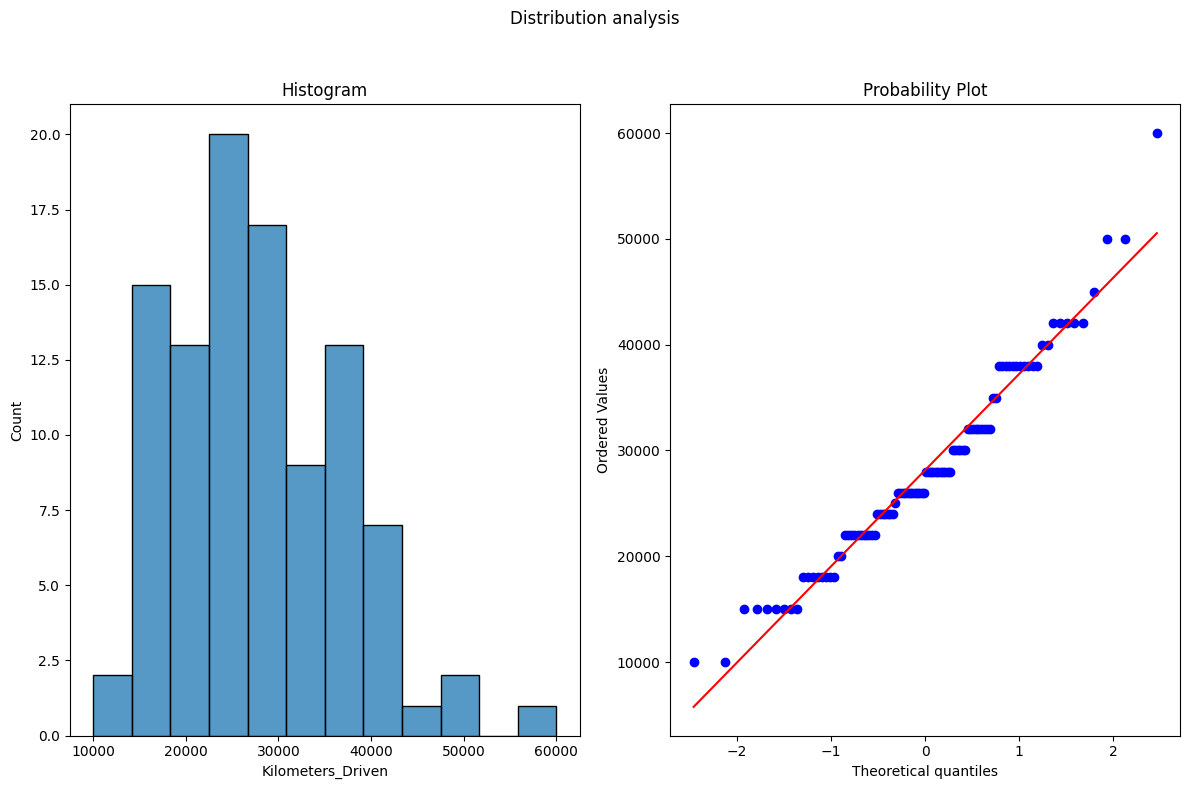

In [10]:
distribution_plot(cars_df['Kilometers_Driven'])

In [11]:
fig = px.histogram(cars_df,
                   x = 'Kilometers_Driven',
                   marginal = 'box',
                   nbins = 20,
                   title = 'Distribution of Kilometers Driven'

)

fig.update_layout(bargap = 0.1)
fig.show()

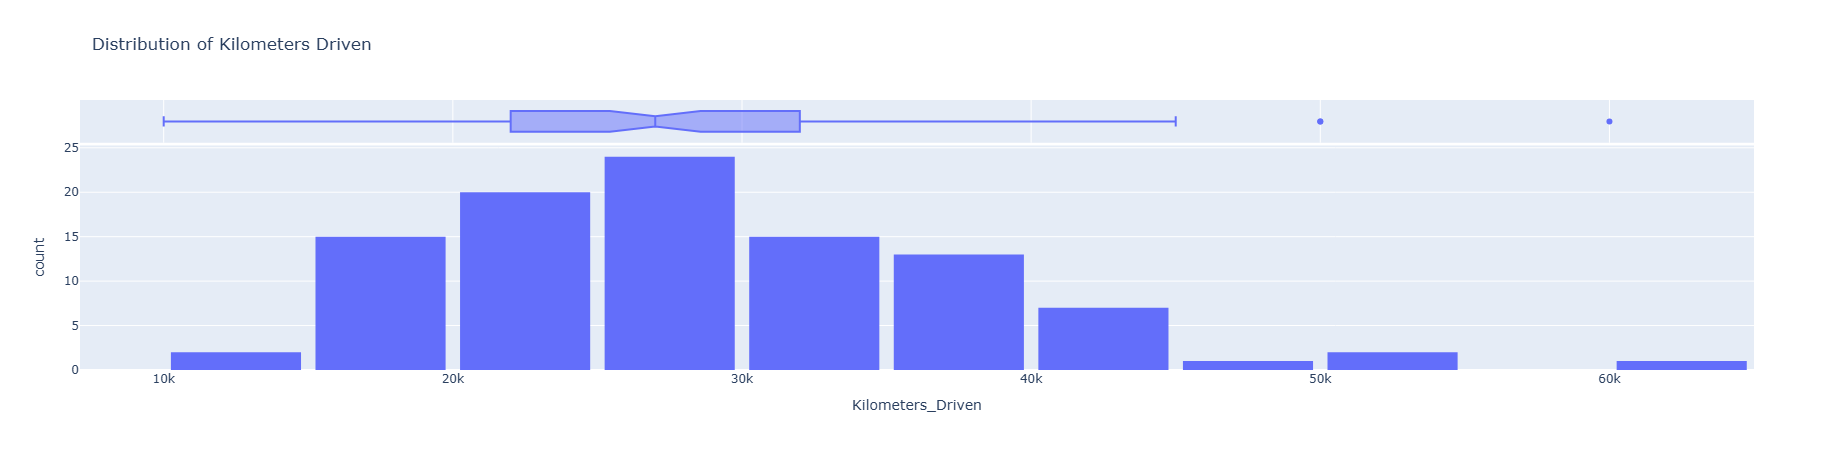

The total mileage of the car is also not normally distributed and is represented by a right-skewed distribution, which is reflected in the excess of the mean over the median, as well as the QQ-plot. There are outliers in the data, namely 50 and 60 thousand kilometers, this mileage may correspond to reality, therefore, most likely, these are rare, but possible cases, which are also important in the analysis.

- Minimum mileage: 22 thousand km
- Maximum mileage: 32 thousand km
- Average mileage: 28.15 thousand km
- Median mileage: 27 thousand km

### Mileage

In [12]:
cars_df['Mileage'].describe(percentiles=[0.99, 0.999])

count    100.000000
mean      17.210000
std        3.309902
min       10.000000
50%       17.000000
99%       25.000000
99.9%     25.000000
max       25.000000
Name: Mileage, dtype: float64

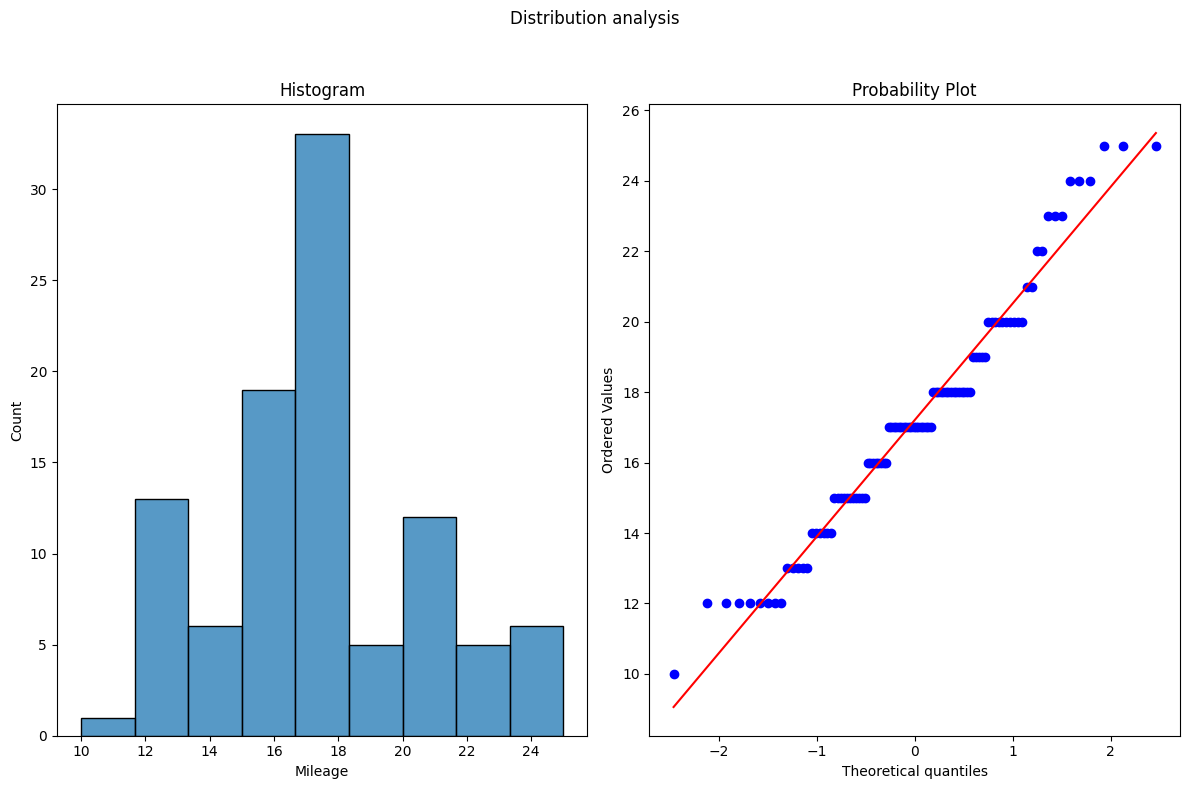

In [13]:
distribution_plot(cars_df['Mileage'])

In [14]:
fig = px.histogram(cars_df,
                   x = 'Mileage',
                   marginal = 'box',
                   nbins = 20,
                   title = 'Distribution of Mileage'

)

fig.update_layout(bargap = 0.1)
fig.show()

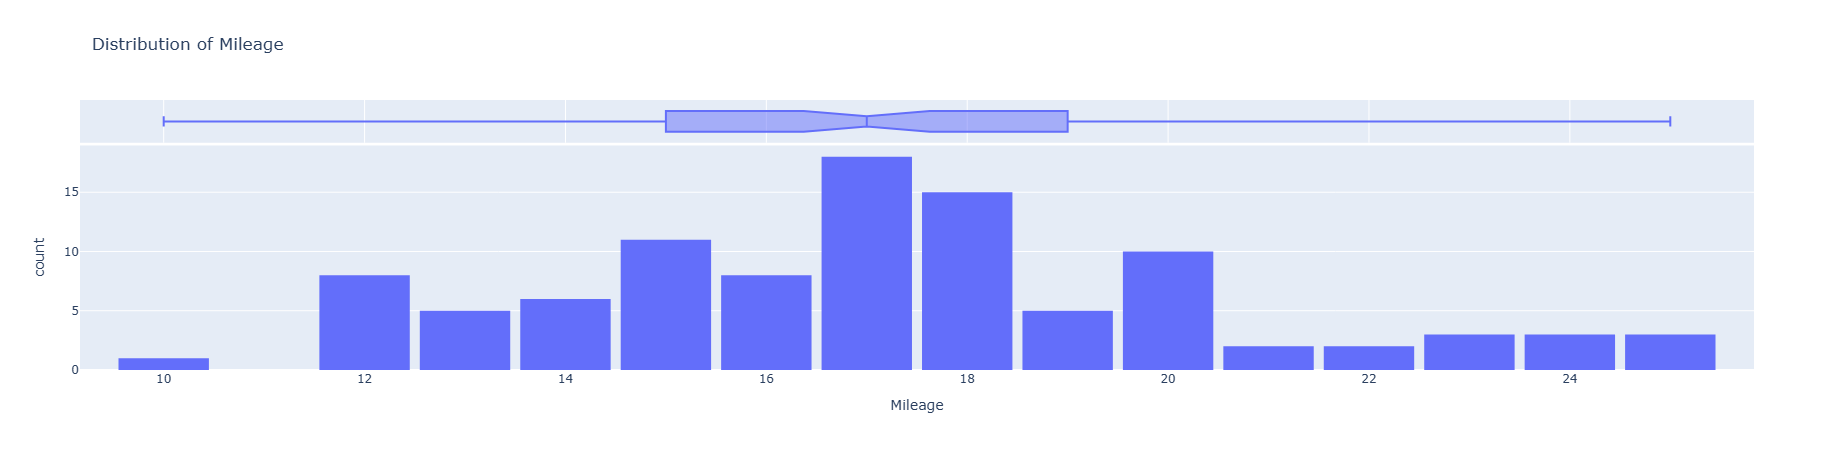

The fuel efficiency of the car is close to a normal distribution, but according to a QQ-plot with a deviation in the tails, which does not allow us to consider it as a strictly normal distribution. There are no outliers in the data.

- Minimum fuel consumption: 15 km/l
- Maximum fuel consumption: 19 km/l
- Average consumption: 17.21 km/l
- Median value: 17 km/l

### Engine

In [15]:
cars_df['Engine'].describe(percentiles=[0.99, 0.999])

count     100.000000
mean     1855.230000
std       631.311475
min       999.000000
50%      1774.000000
99%      3017.530000
99.9%    4757.653000
max      4951.000000
Name: Engine, dtype: float64

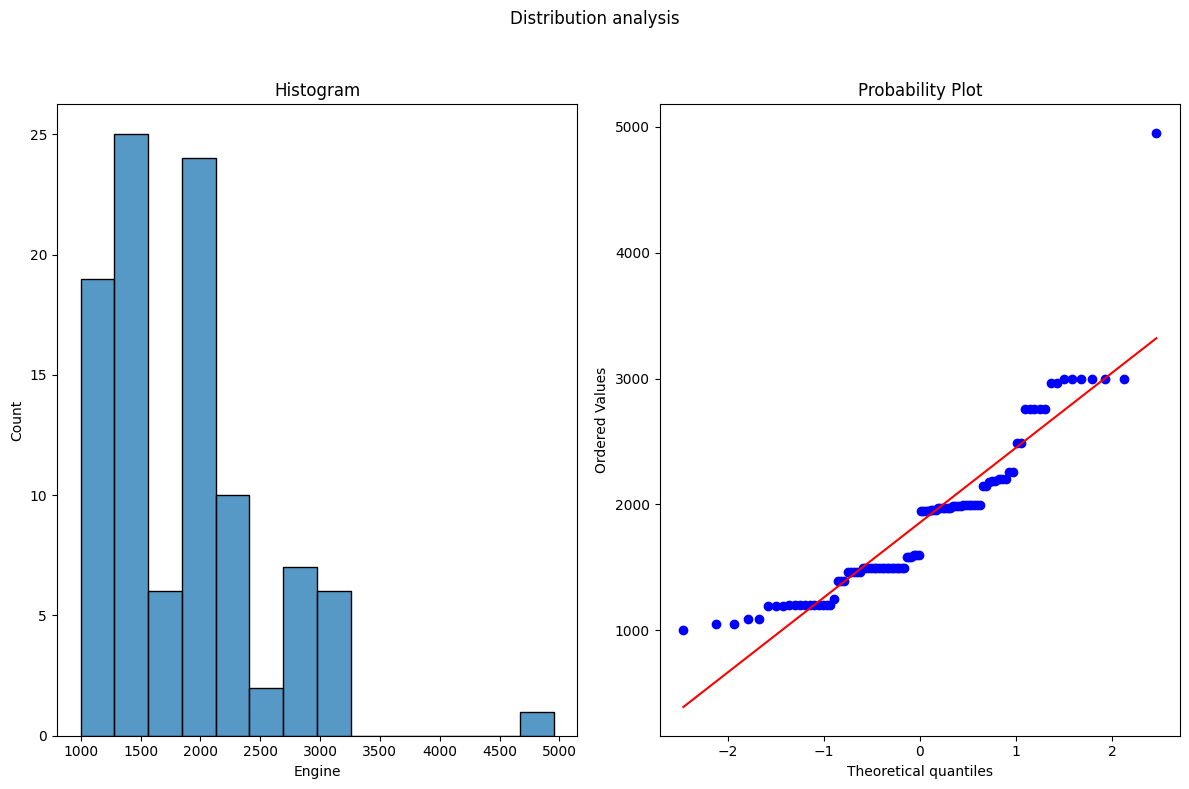

In [16]:
distribution_plot(cars_df['Engine'])

In [17]:
fig = px.histogram(cars_df,
                   x = 'Engine',
                   marginal = 'box',
                   nbins = 20,
                   title = 'Distribution of Engine'

)

fig.update_layout(bargap = 0.1)
fig.show()

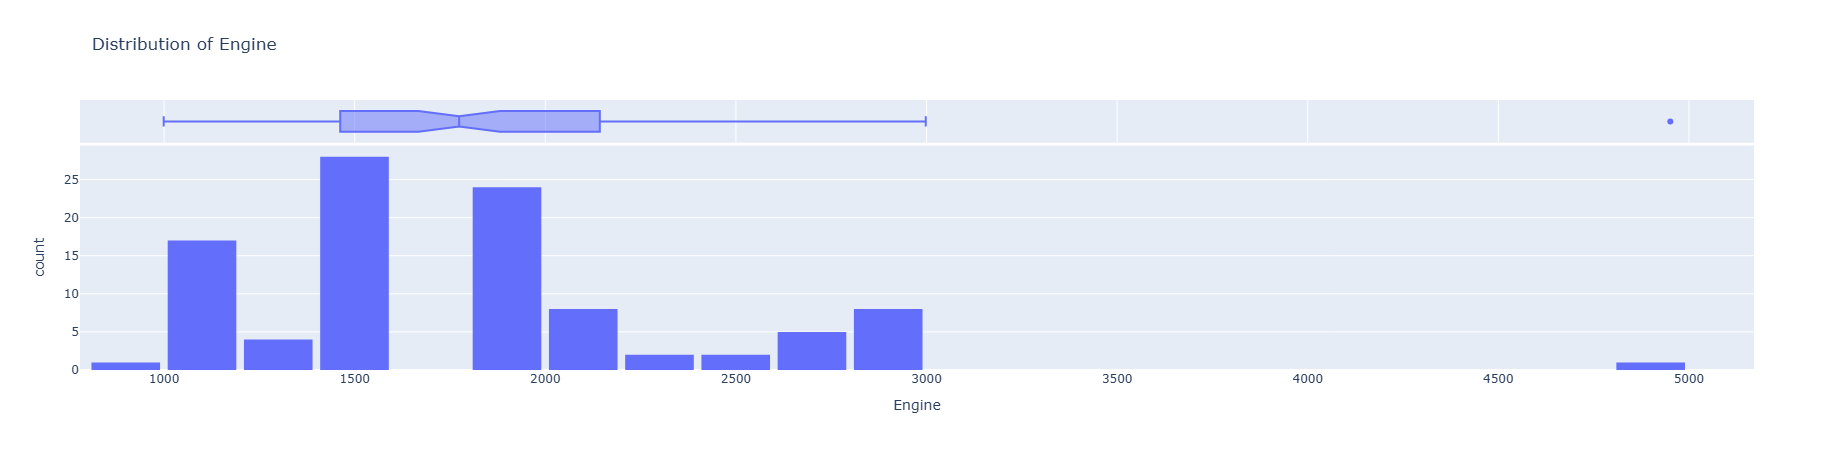

The fuel efficiency of the car is also not normally distributed, the distribution is right-skewed. Emissions in the data are present in the case of 4951 CC.

- Minimum engine displacement: 1462 CC
- Maximum engine displacement: 2143 CC
- Mean displacement: 1855 CC
- Median value: 1774 CC

### Power

In [18]:
cars_df['Power'].describe(percentiles=[0.99, 0.999])

count    100.000000
mean     158.130000
std       76.968137
min       68.000000
50%      148.000000
99%      396.000000
99.9%    396.000000
max      396.000000
Name: Power, dtype: float64

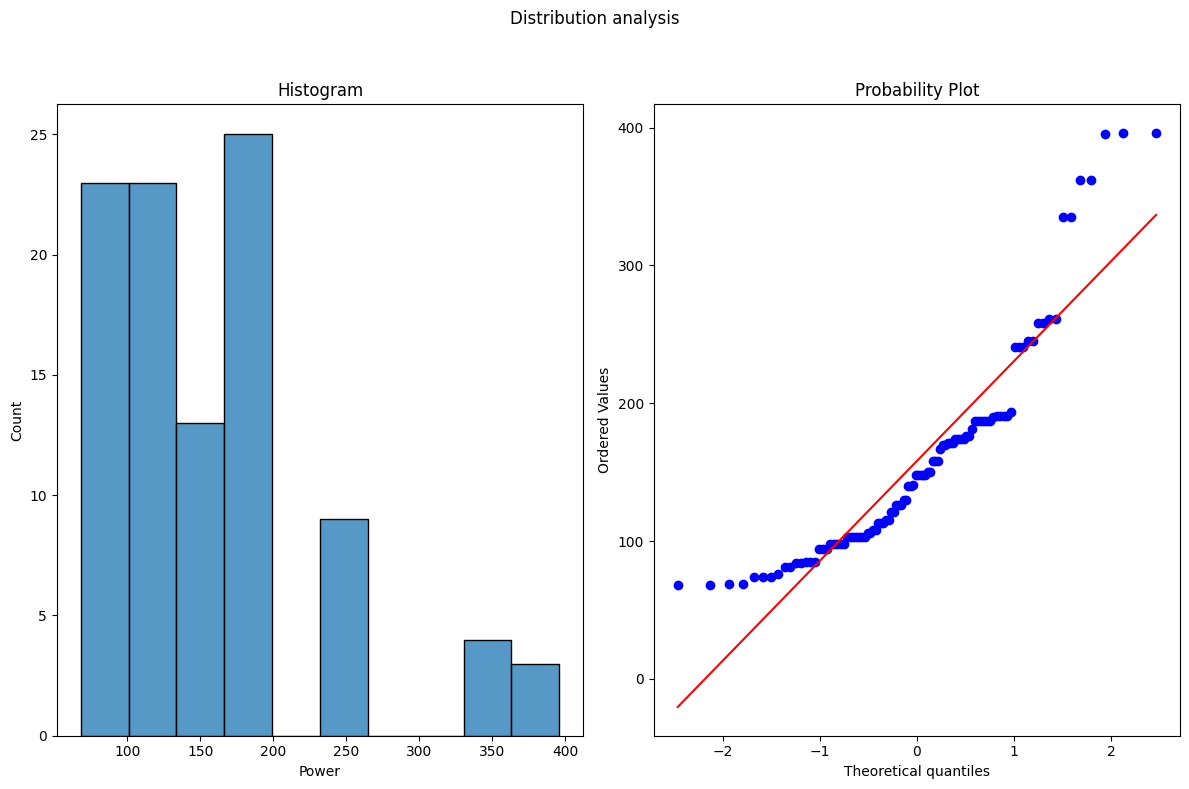

In [19]:
distribution_plot(cars_df['Power'])

In [20]:
fig = px.histogram(cars_df,
                   x = 'Power',
                   marginal = 'box',
                   nbins = 20,
                   title = 'Distribution of Power'

)

fig.update_layout(bargap = 0.1)
fig.show()

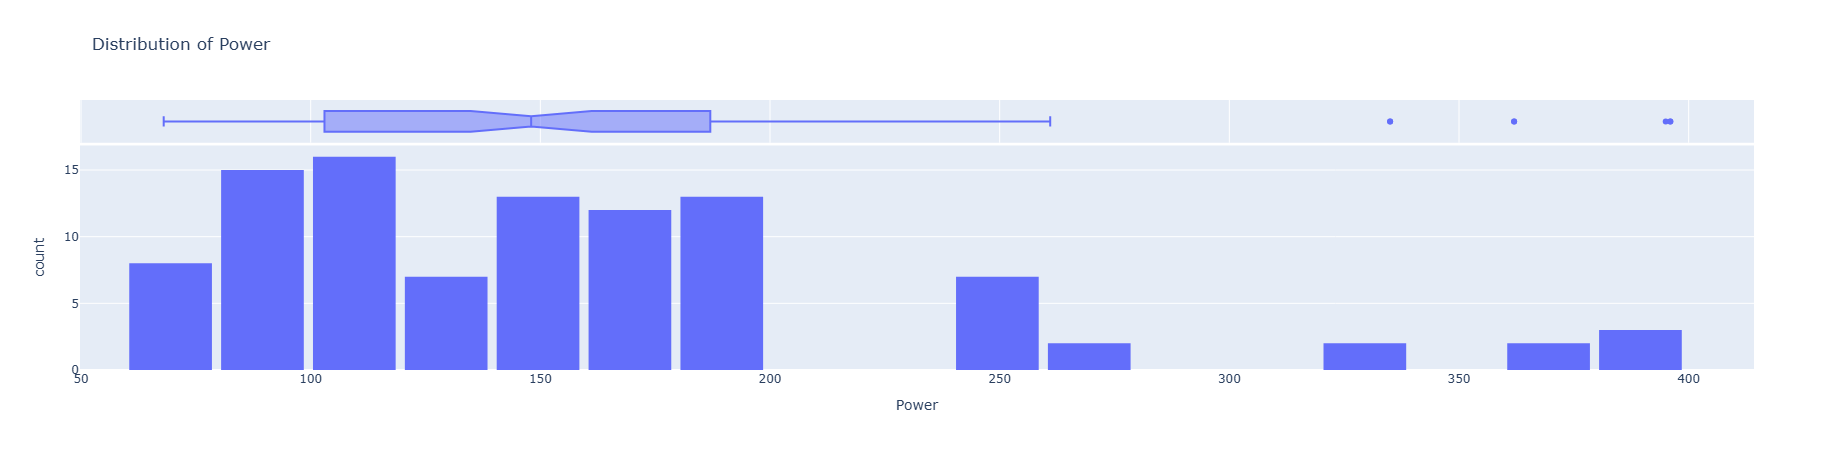

The power of the car is also not normally distributed, but is represented by a right-skewed distribution. The emissions in the data are present in the range of 320-400 bhp.

- Minimum power: 187 bhp
- Maximum power: 103 bhp
- Mean value: 158.13 bhp
- Median value: 148 bhp

### Year

In [21]:
cars_df['Year'].describe(percentiles=[0.99, 0.999])

count     100.00000
mean     2018.39000
std         1.17116
min      2016.00000
50%      2018.00000
99%      2021.00000
99.9%    2021.00000
max      2021.00000
Name: Year, dtype: float64

In [22]:
print("Унікальна кількість років:", cars_df['Year'].nunique())

Унікальна кількість років: 6


In [23]:
year_counts = cars_df['Year'].value_counts()
year_proportion = (cars_df['Year'].value_counts(normalize = True) * 100).round(2)

year_values = pd.DataFrame({
    "count": year_counts,
    "proportion": year_proportion
})

year_values


,count,proportion
Year,,
2018,28,28.0
2019,28,28.0
2017,21,21.0
2020,17,17.0
2016,4,4.0
2021,2,2.0


In [24]:
fig = px.histogram(cars_df,
                   x = 'Year',
                   title = 'Distribution of Year'

)

fig.update_layout(bargap = 0.1)
fig.show()

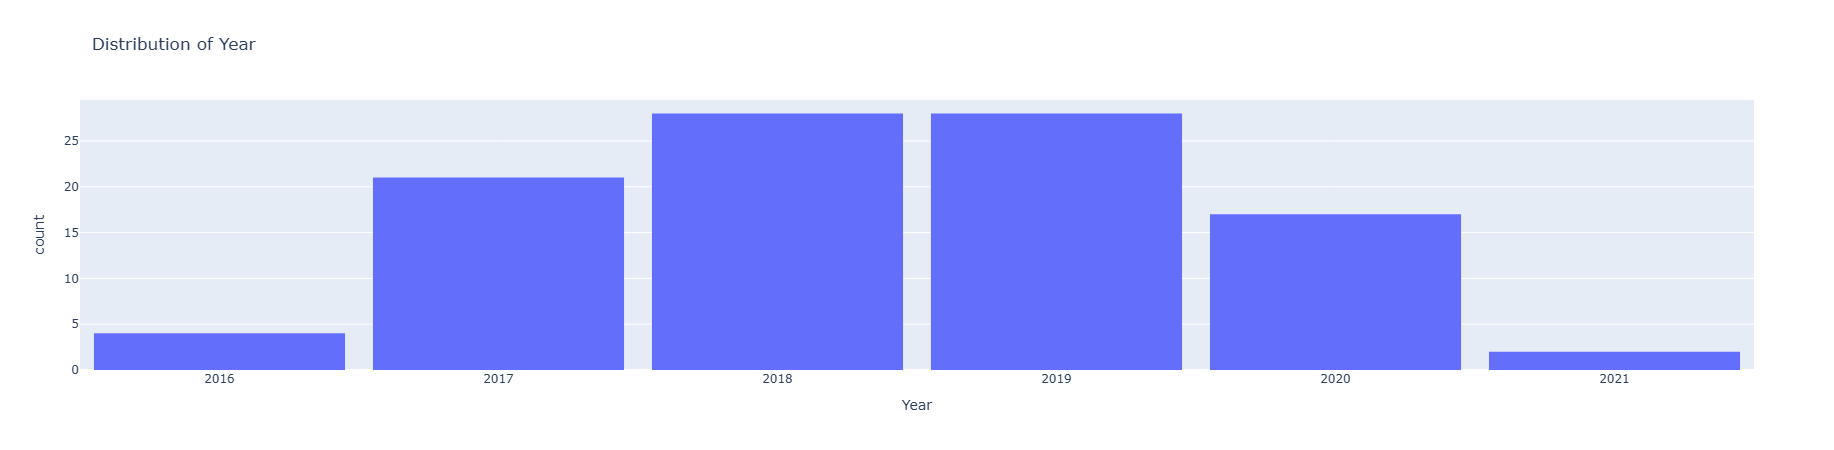

About 50% of the data reflects data from cars from 2018-2019, with only 6% accounting for the oldest and newest data from cars from 2016 and 2021, respectively.

- Minimum year: 2016
- Maximum year: 2021
- Average value: 2018
- Median value: 2018

As an option for training data, it is possible to use not the actual value of the year of manufacture of the car, but the age of the car relative to the year of modeling.

### Seats

In [25]:
cars_df['Seats'].describe(percentiles=[0.99, 0.999])

count    100.000000
mean       5.230000
std        0.750151
min        4.000000
50%        5.000000
99%        7.000000
99.9%      7.000000
max        7.000000
Name: Seats, dtype: float64

In [26]:
seats_counts = cars_df['Seats'].value_counts()
seats_proportion = (cars_df['Seats'].value_counts(normalize = True) * 100).round(2)

seats_values = pd.DataFrame({
    "count": seats_counts,
    "proportion": seats_proportion
})

seats_values


,count,proportion
Seats,,
5,81,81.0
7,14,14.0
4,5,5.0


In [27]:
fig = px.histogram(cars_df,
                   x = 'Seats',
                   title = 'Distribution of Seats'

)

fig.update_layout(bargap = 0.1)
fig.show()

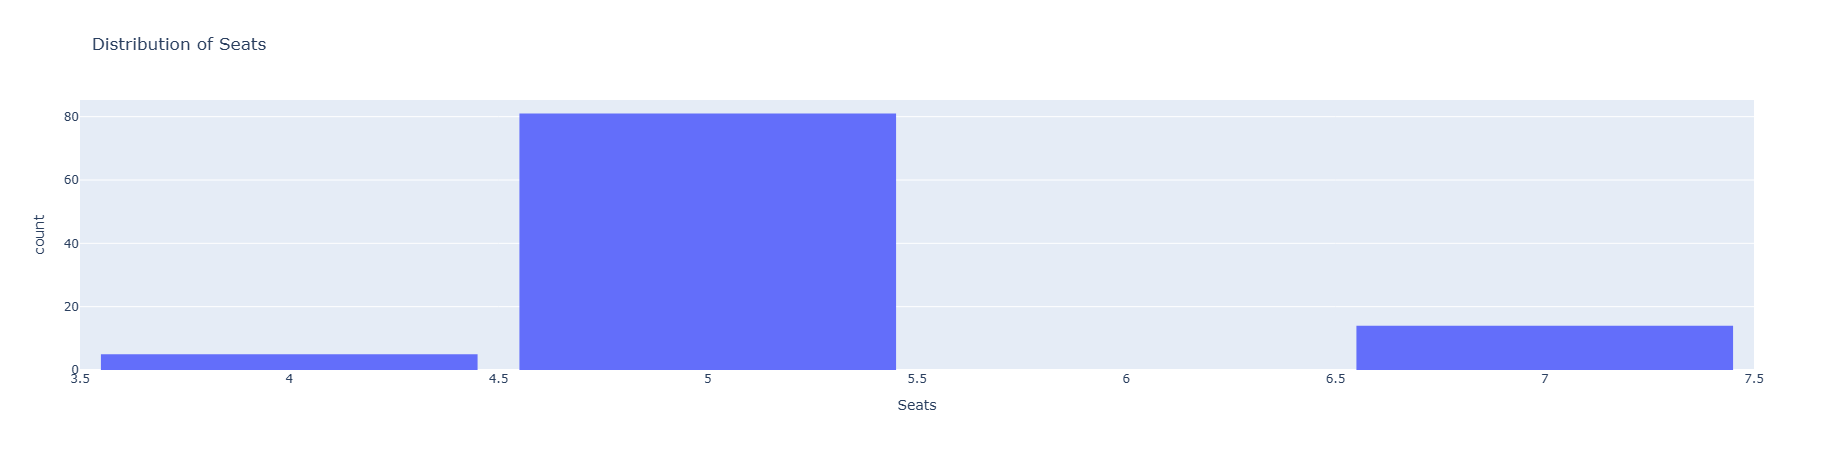

The number of seats in a car, although it is a numerical characteristic, can be classified as a categorical characteristic in its content. There is a small number of 4- and 7-seater cars in the data. About 81% of the data reflect 5-seater cars.

- Minimum number of seats: 4
- Maximum number of seats: 7
- Average value: 5.23
- Median value: 5

### Transmission

In [28]:
print("Унікальна кількість типу трансмісії:", cars_df['Transmission'].nunique())

Унікальна кількість типу трансмісії: 2


In [29]:
transmission_counts = cars_df['Transmission'].value_counts()
transmission_proportion = (cars_df['Transmission'].value_counts(normalize = True) * 100).round(2)

transmission_values = pd.DataFrame({
    "count": transmission_counts,
    "proportion": transmission_proportion
})

transmission_values

,count,proportion
Transmission,,
Automatic,57,57.0
Manual,43,43.0


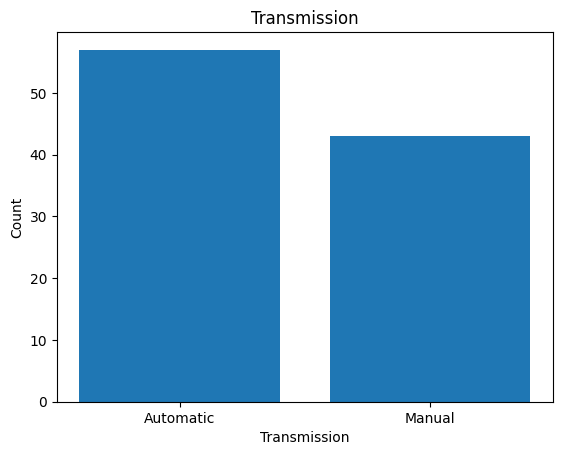

In [30]:
plt.bar(transmission_values.index, transmission_values['count'])
plt.xlabel('Transmission')
plt.ylabel('Count')
plt.title('Transmission')
plt.show();

According to our dataset, about 57% have an automatic transmission, and 43% have a manual transmission.

### Owner type

In [31]:
print("Унікальна кількість типів власників:", cars_df['Owner_Type'].nunique())

Унікальна кількість типів власників: 3


In [32]:
owner_counts = cars_df['Owner_Type'].value_counts()
owner_proportion = (cars_df['Owner_Type'].value_counts(normalize = True) * 100).round(2)

owner_values = pd.DataFrame({
    "count": owner_counts,
    "proportion": owner_proportion
})

owner_values

,count,proportion
Owner_Type,,
First,44,44.0
Second,43,43.0
Third,13,13.0


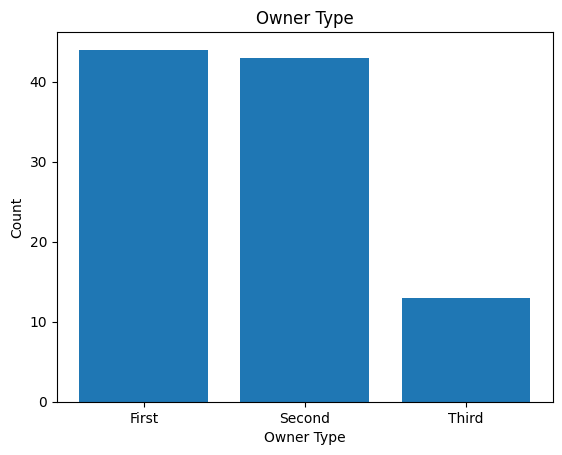

In [33]:
plt.bar(owner_values.index, owner_values['count'])
plt.xlabel('Owner Type')
plt.ylabel('Count')
plt.title('Owner Type')
plt.show();

In [34]:
fig = px.histogram(cars_df,
                   x = 'Owner_Type',
                   color = 'Transmission',
                   title = 'Owner Type by Transmission'

)

fig.update_layout(bargap = 0.1)
fig.show()

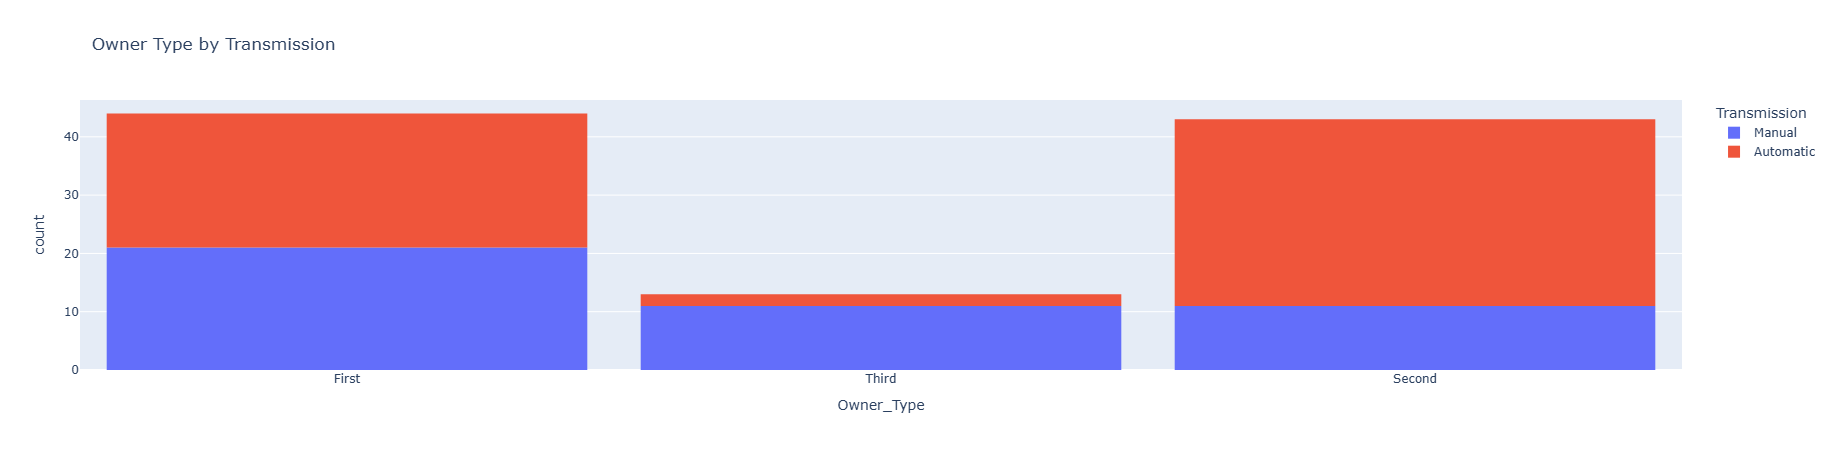

In [35]:
fig = px.histogram(cars_df,
                   x = 'Owner_Type',
                   color = 'Year',
                   title = 'Owner Type by Transmission'

)

fig.update_layout(bargap = 0.1)
fig.show()

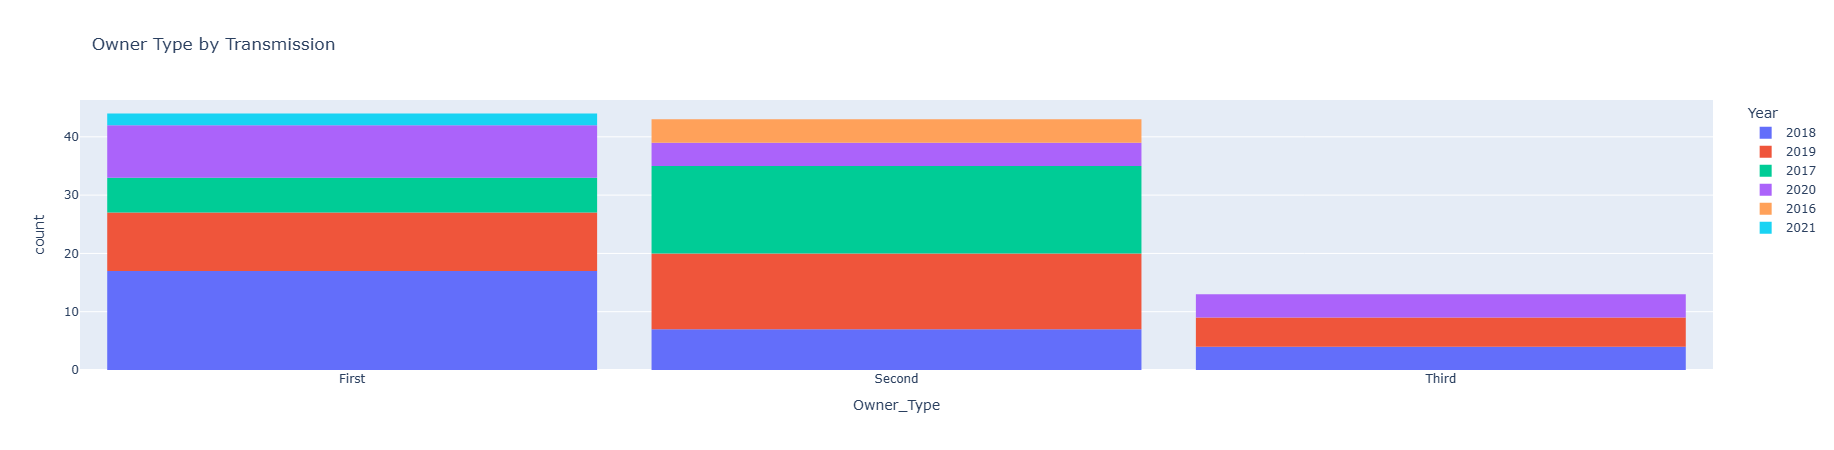

The majority of cars had one or two owners. Only 13% of ads had three owners, and the majority of these were cars with manual transmissions and 6-8 years old from the year of manufacture.

### Fuel type

In [36]:
print("Унікальна кількість типів палива:", cars_df['Fuel_Type'].nunique())

Унікальна кількість типів палива: 2


In [37]:
fuel_counts = cars_df['Fuel_Type'].value_counts()
fuel_proportion = (cars_df['Fuel_Type'].value_counts(normalize = True) * 100).round(2)

fuel_values = pd.DataFrame({
    "count": fuel_counts,
    "proportion": fuel_proportion
})

fuel_values

,count,proportion
Fuel_Type,,
Petrol,52,52.0
Diesel,48,48.0


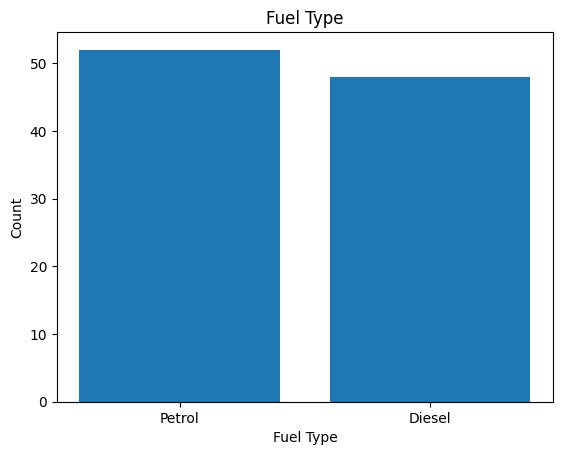

In [38]:
plt.bar(fuel_values.index, fuel_values['count'])
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.title('Fuel Type')
plt.show();

Cars are evenly represented by fuel type: 52% - gasoline, 48% - diesel.

### Model

In [39]:
print("Унікальна кількість моделей:", cars_df['Model'].nunique())

Унікальна кількість моделей: 58


In [40]:
model_counts = cars_df['Model'].value_counts()
model_proportion = (cars_df['Model'].value_counts(normalize = True) * 100).round(2)

model_values = pd.DataFrame({
    "count": model_counts,
    "proportion": model_proportion
})

model_values.sort_values(by = 'proportion', ascending = False).head(10)

,count,proportion
Model,,
Mustang,3,3.0
C-Class,3,3.0
Altroz,3,3.0
Verna,3,3.0
Passat,2,2.0
Thar,2,2.0
T-Roc,2,2.0
BR-V,2,2.0
S-Cross,2,2.0


In [41]:
fig = px.histogram(cars_df,
                   x = 'Model',
                   title = 'Models',
)

fig.update_layout(bargap = 0.1)
fig.show()

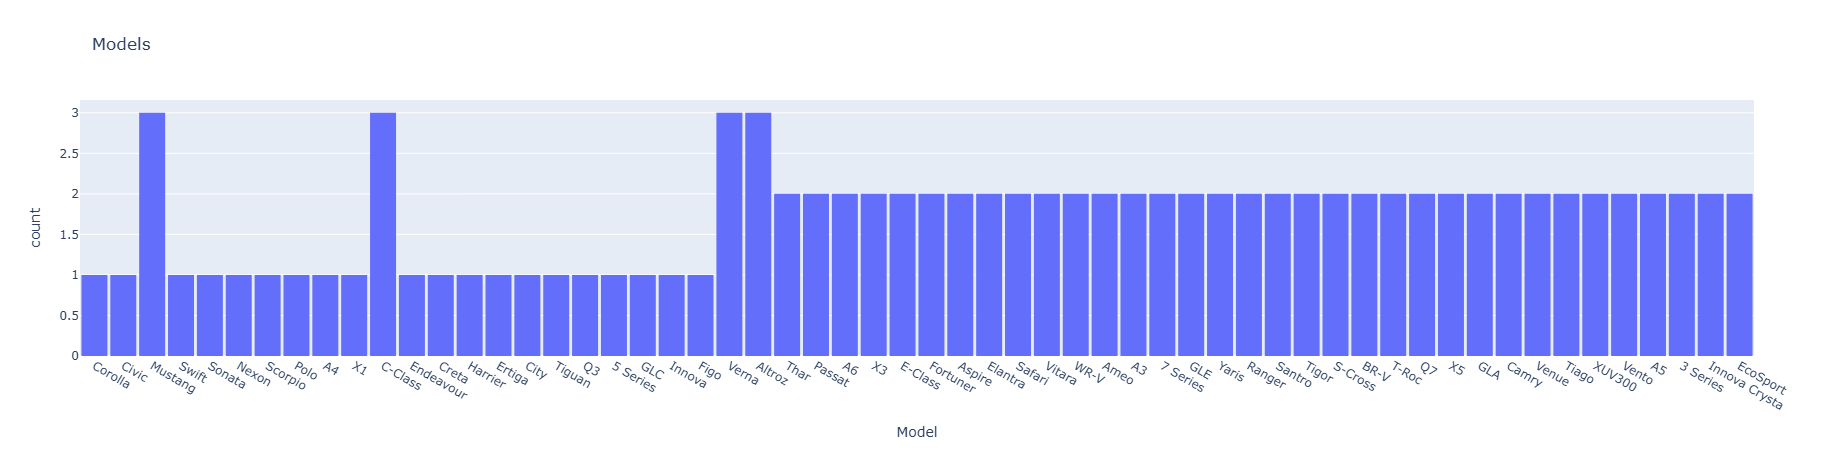

Each car model is represented by 1-3 ads.

### Brand

In [42]:
print("Унікальна кількість брендів:", cars_df['Brand'].nunique())

Унікальна кількість брендів: 11


In [43]:
brand_counts = cars_df['Brand'].value_counts()
brand_proportion = (cars_df['Brand'].value_counts(normalize = True) * 100).round(2)

brand_values = pd.DataFrame({
    "count": brand_counts,
    "proportion": brand_proportion
})

brand_values.sort_values(by = 'proportion', ascending = False).head(10)

,count,proportion
Brand,,
Ford,11,11.0
Tata,11,11.0
Hyundai,11,11.0
BMW,10,10.0
Toyota,10,10.0
Audi,10,10.0
Volkswagen,10,10.0
Mercedes,10,10.0
Honda,6,6.0


In [44]:
fig = px.histogram(cars_df,
                   x = 'Brand',
                   title = 'Brand',
)

fig.update_layout(bargap = 0.1)
fig.show()

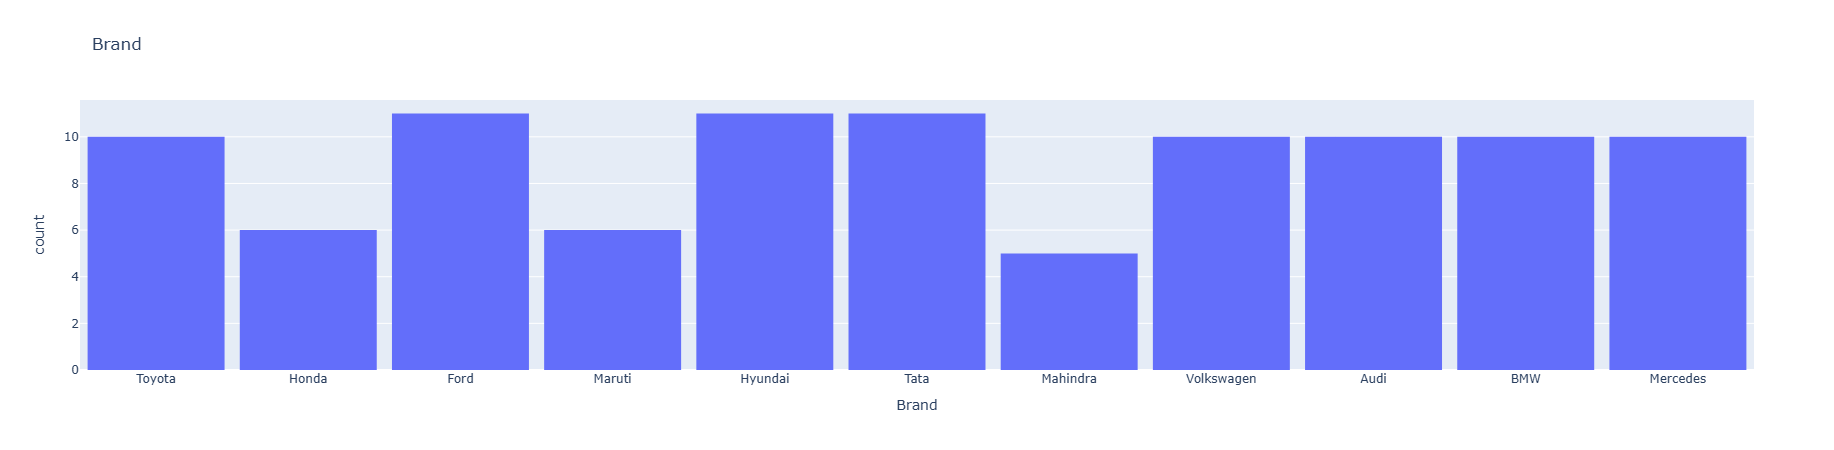

The dataset represents ads from 11 unique brands. Only 3 of them are featured in only 5-6 ads (Honda, Maruti, Mahindra), all other brands have 10-11 ads each.

# Data preparation for modeling

## Завдання 3

In [45]:
target_col = 'Price'
y = cars_df[target_col]
X = cars_df.drop(columns = [target_col])

In [46]:
print("Дизайн матриця")
X.head(5)

Дизайн матриця


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5


In [47]:
print("Цільова метрика")
y.head(5)

Цільова метрика


0     800000
1    1000000
2    2500000
3     600000
4     850000
Name: Price, dtype: int64

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 12)

In [49]:
print("Розмір ознак навчального набору:", X_train.shape)
print("Розмір цільової метрики навчального набору:", y_train.shape)
print("Розмір ознак тестового набору:", X_test.shape)
print("Розмір цільової метрики тестового набору:", y_test.shape)

Розмір ознак навчального набору: (80, 12)
Розмір цільової метрики навчального набору: (80,)
Розмір ознак тестового набору: (20, 12)
Розмір цільової метрики тестового набору: (20,)


In [50]:
print("Дизайн матриця навчального набору")
display(X_train.head(5))
print("Цільова метрика навчального набору")
(y_train.head(5))


Дизайн матриця навчального набору


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5


Цільова метрика навчального набору


83    1600000
55    2600000
26    3200000
54     650000
19    2500000
Name: Price, dtype: int64

### Fuel_Type encoding

In [51]:
fuel_values

,count,proportion
Fuel_Type,,
Petrol,52,52.0
Diesel,48,48.0


In [52]:
fuel_codes = {'Diesel': 0, 'Petrol': 1}
X_train['Fuel_Code'] = X_train['Fuel_Type'].map(fuel_codes) 

In [53]:
X_train[['Fuel_Code', 'Fuel_Type']].head()

,Fuel_Code,Fuel_Type
83,1,Petrol
55,0,Diesel
26,1,Petrol
54,1,Petrol
19,1,Petrol


In [54]:
X_test['Fuel_Code'] = X_test['Fuel_Type'].map(fuel_codes) 

In [55]:
X_test[['Fuel_Code', 'Fuel_Type']].head()

,Fuel_Code,Fuel_Type
17,1,Petrol
41,1,Petrol
92,1,Petrol
14,1,Petrol
68,1,Petrol


### Transmission encoding

In [56]:
transmission_values

,count,proportion
Transmission,,
Automatic,57,57.0
Manual,43,43.0


In [57]:
transmission_code = {'Manual': 0, 'Automatic': 1}
X_train['Transmission_Code'] = X_train['Transmission'].map(transmission_code)

In [58]:
X_train[['Transmission_Code', 'Transmission']].head()

,Transmission_Code,Transmission
83,1,Automatic
55,1,Automatic
26,1,Automatic
54,0,Manual
19,1,Automatic


In [59]:
X_test['Transmission_Code'] = X_test['Transmission'].map(transmission_code)

In [60]:
X_test[['Transmission_Code', 'Transmission']].head()

,Transmission_Code,Transmission
17,1,Automatic
41,0,Manual
92,0,Manual
14,0,Manual
68,0,Manual


### Brand Coding

In [61]:
enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Brand']])
enc.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [62]:
one_hot_train = enc.transform(X_train[['Brand']]).toarray()
one_hot_train[:5]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]])

In [63]:
X_train[enc.categories_[0]] = one_hot_train

In [64]:
X_train.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,...,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [65]:
one_hot_test = enc.transform(X_test[['Brand']]).toarray()
one_hot_test[:5]

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [66]:
X_test[enc.categories_[0]] = one_hot_test

In [67]:
X_test.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,...,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Owner_Type encoding

In [68]:
ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Expected result after transformations:

In [69]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head());

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


There is a so-called ordinal encoding, where the numbers 1, 2, 3, etc. are assigned in the specified order. So, since in Python we usually start with 0, the category of cars with one owner corresponds to 0, with two - 1, with three - 2.

# Correlation

In [70]:
numeric_cols_train = X_train.select_dtypes("number").drop(columns = ['Car_ID'])
numeric_cols_train.head()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [71]:
numeric_train = pd.concat([numeric_cols_train, y_train], axis = 1)
numeric_train.head()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Price
83,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1600000
55,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2600000
26,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3200000
54,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,650000
19,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2500000


In [72]:
corr = numeric_train.corr()
corr.style.background_gradient().format("{:.4f}")

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Price
Year,1.0000,-0.7085,0.2786,-0.3928,-0.2484,-0.2788,0.2485,-0.2006,-0.2565,0.2025,-0.1505,-0.0374,-0.0921,0.1817,0.2851,-0.1152,0.2487,-0.2193,0.0183,-0.0145,-0.2338
Kilometers_Driven,-0.7085,1.0000,-0.1266,0.1012,-0.0608,0.4037,-0.3324,-0.0665,0.0959,-0.2470,-0.0098,0.0574,0.1544,-0.0403,-0.1904,-0.0917,0.0304,0.3685,-0.1377,-0.0018,-0.0840
Mileage,0.2786,-0.1266,1.0000,-0.7105,-0.6847,-0.1786,-0.0701,-0.3992,-0.1527,-0.1341,-0.2965,0.3586,0.2174,0.0294,0.1164,-0.2385,0.3477,-0.2016,0.0851,0.0266,-0.6384
Engine,-0.3928,0.1012,-0.7105,1.0000,0.8016,0.1673,-0.1745,0.4563,0.0852,0.2871,0.1842,-0.1545,-0.1822,-0.0250,-0.1933,0.1639,-0.3401,0.2349,-0.1651,-0.1961,0.7106
Power,-0.2484,-0.0608,-0.6847,0.8016,1.0000,-0.1394,0.0764,0.5869,0.1570,0.3727,0.2405,-0.1918,-0.1710,-0.1180,-0.2210,0.2808,-0.3170,-0.0405,-0.1484,-0.2043,0.8491
Seats,-0.2788,0.4037,-0.1786,0.1673,-0.1394,1.0000,-0.4125,-0.0701,0.1237,-0.1081,-0.1615,0.2003,-0.0864,0.0077,-0.0784,-0.1081,-0.0127,0.3485,-0.0940,-0.0438,0.0010
Fuel_Code,0.2485,-0.3324,-0.0701,-0.1745,0.0764,-0.4125,1.0000,-0.0058,-0.0083,-0.0485,0.1098,-0.1614,-0.0071,-0.2352,0.1485,-0.0485,0.0662,-0.0083,0.1250,0.2811,-0.1108
Transmission_Code,-0.2006,-0.0665,-0.3992,0.4563,0.5869,-0.0701,-0.0058,1.0000,0.2651,0.2832,-0.1228,-0.2186,0.0317,-0.1707,-0.1126,0.2832,-0.3976,-0.0770,0.1555,0.0059,0.6807
Audi,-0.2565,0.0959,-0.1527,0.0852,0.1570,0.1237,-0.0083,0.2651,1.0000,-0.1187,-0.1187,-0.0861,-0.0949,-0.0765,-0.0861,-0.1187,-0.1260,-0.1111,-0.1032,-0.2039,0.3289
BMW,0.2025,-0.2470,-0.1341,0.2871,0.3727,-0.1081,-0.0485,0.2832,-0.1187,1.0000,-0.1268,-0.0919,-0.1014,-0.0817,-0.0919,-0.1268,-0.1346,-0.1187,-0.1103,0.0091,0.4775


In [73]:
threshold = 0.5
corr_y = corr['Price']
strong_corr = corr_y[corr_y.abs() > threshold]
strong_corr

Mileage             -0.638404
Engine               0.710561
Power                0.849137
Transmission_Code    0.680731
Price                1.000000
Name: Price, dtype: float64

The greatest positive relationship is observed between the price of a car and the power of the car. There is also a direct relationship with the engine size and transmission type. Accordingly, as the attribute increases, the modeled variable increases.
A strong inverse relationship is also observed between the price of a car and the fuel efficiency of a car. Accordingly, the lower the fuel consumption, the higher the price of the car.

# Model building

In [74]:
numeric_cols_test = X_test.select_dtypes("number").drop(columns = ['Car_ID'])
numeric_cols_test.head()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,2016,38000,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,2019,26000,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,2020,18000,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,2019,26000,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


In [75]:
model_1 = LinearRegression().fit(numeric_cols_train, y_train)

In [76]:
model_1_coef = pd.DataFrame({
    "feature": np.append(numeric_cols_train.columns, 1),
    "coefficient": np.append(model_1.coef_, model_1.intercept_)
})

model_1_coef.sort_values('coefficient', ascending = False)

,feature,coefficient
20,1,2.252979e+07
8,Audi,7.588030e+05
15,Mercedes,7.339747e+05
9,BMW,7.303268e+05
7,Transmission_Code,2.363676e+05
17,Toyota,1.304575e+05
19,Owner_Type_Codes,6.627831e+04
4,Power,6.140756e+03
1,Kilometers_Driven,-1.087444e+01
3,Engine,-3.758587e+01


In [77]:
prediction_1_train = model_1.predict(numeric_cols_train)
prediction_1_test = model_1.predict(numeric_cols_test)

In [78]:
rmse_1_train = np.sqrt(mean_squared_error(y_train, prediction_1_train)).round(4)
rmse_1_test = np.sqrt(mean_squared_error(y_test, prediction_1_test)).round(4)

print("Train RMSE:", rmse_1_train)
print("Test RMSE:", rmse_1_test)

Train RMSE: 210342.8016
Test RMSE: 259601.2654


In [79]:
std_1_train = np.std(y_train).round(4)
std_1_test = np.std(y_test).round(4)

print("Стандартне відхилення Train:", std_1_train)
print("Стандартне відхилення Test:", std_1_test)

Стандартне відхилення Train: 1033882.2467
Стандартне відхилення Test: 672495.3531


In [80]:
r2_1_train = round(r2_score(y_train, prediction_1_train), 4)
r2_1_test = round(r2_score(y_test, prediction_1_test), 4)

print("Train R^2:", r2_1_train)
print("Test R^2:", r2_1_test)

Train R^2: 0.9586
Test R^2: 0.851


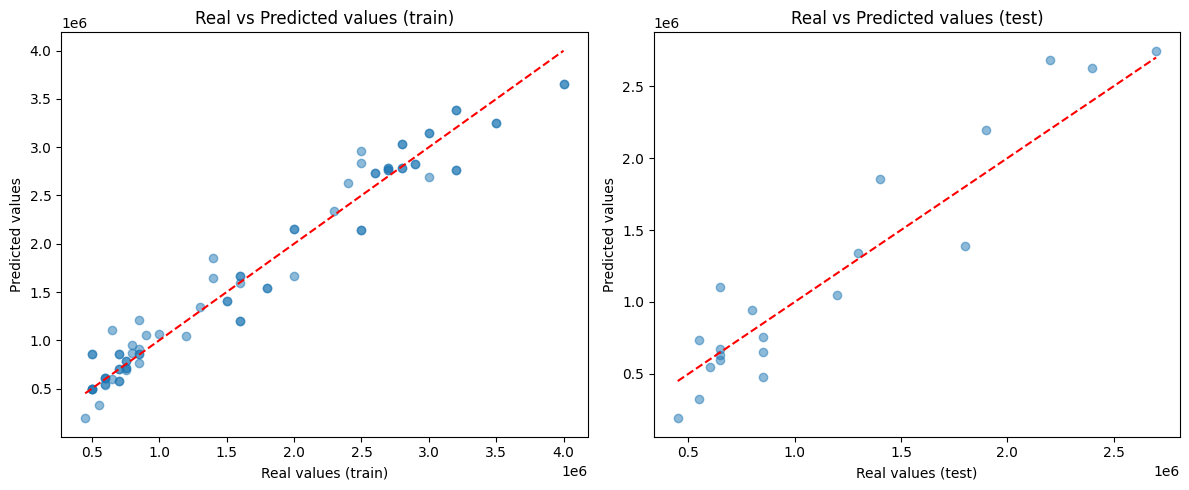

In [81]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

axes[0].scatter(y_train, prediction_1_train, alpha = 0.5)
axes[0].plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         'r--')
axes[0].set_xlabel("Real values (train)")
axes[0].set_ylabel("Predicted values")
axes[0].set_title("Real vs Predicted values (train)")

axes[1].scatter(y_test, prediction_1_test, alpha = 0.5)
axes[1].plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
axes[1].set_xlabel("Real values (test)")
axes[1].set_ylabel("Predicted values")
axes[1].set_title("Real vs Predicted values (test)")

plt.tight_layout()
plt.show();

According to the results of the constructed model, we can see that the results are generally good. On the training data, the model describes 95.68% of the modeled variable due to the selected features, on the test data the figure is slightly lower - 85.1%. At the same time, the RMSE is at the level of 210342.80 INR in the case of the training set and 259601.27 INR on the test set. Accordingly, on the test set the error is larger, and corresponds to about 1/3 of the standard deviation.

Regarding the scatter plots, on the training set the points are quite densely located along the bisector. There is no obvious scatter. The model learns well.
On the test set the points are not so densely located, although there is no certain wide scatter. The model also shows good results, although slightly worse than on the training data.

In [82]:
numeric_cols_train_intercept = sm.add_constant(numeric_cols_train)
model_1_stats = sm.OLS(y_train, numeric_cols_train_intercept).fit()

In [83]:
print(model_1_stats.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     73.14
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           2.34e-34
Time:                        02:17:15   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2228.
Df Residuals:                      60   BIC:                             2276.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              2.065e+07    9.6e+0

The result of building via statsmodels corresponds to that obtained via sklearn. From more detailed statistics, we can see that our model is adequate, since the p-value (F-statistic) is less than 0.05. At the same time, a number of features are not statistically significant, since their p-value of the t-statistic is more than 0.05 (for example, Year, Kilometers_Driven, Engine, etc.). We also have information about the possible presence of multicodynearism.

## Scalling

In [84]:
scaler = StandardScaler().fit(numeric_cols_train)

scaled_train = scaler.transform(numeric_cols_train)
scaled_train = pd.DataFrame(scaled_train, 
                            columns = numeric_cols_train.columns, 
                            index = numeric_cols_train.index)

scaled_test = scaler.transform(numeric_cols_test)
scaled_test = pd.DataFrame(scaled_test, 
                           columns = numeric_cols_test.columns,
                           index = numeric_cols_test.index)

In [85]:
print("Масштабовані ознаки навчального набору")
display(scaled_train.head())
print("Масштабовані ознаки тестового набору")
display(scaled_test.head())

Масштабовані ознаки навчального набору


,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,0.568813,-0.693871,0.274862,-0.628491,-0.231967,-0.303562,0.975305,0.795395,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,3.229330,0.535303
55,-0.323442,-0.039533,-0.018324,0.087196,0.247012,-0.303562,-1.025320,0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,-0.309662,-0.994135
26,-0.323442,-0.039533,-0.604696,0.111560,0.910213,-0.303562,0.975305,0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,-0.309662,-0.994135
54,-1.215697,0.396692,0.274862,-0.476217,-0.784634,-0.303562,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,3.229330,0.535303
19,-1.215697,-0.257646,-1.484254,0.122219,0.910213,-0.303562,0.975305,0.795395,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,2.808717,-0.377964,-0.333333,-0.309662,0.535303


Масштабовані ознаки тестового набору


,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,-2.107952,1.051030,-0.604696,-0.785333,-0.231967,-0.303562,0.975305,0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,-0.309662,0.535303
41,0.568813,-0.257646,0.861234,-1.255859,-1.214487,-0.303562,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.258199,3.511885,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,-0.309662,2.064742
92,-1.215697,0.396692,0.274862,-0.476217,-0.784634,-0.303562,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,3.229330,0.535303
14,1.461068,-1.130096,0.568048,-0.683310,-0.784634,2.394771,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,3.872983,-0.356034,-0.377964,-0.333333,-0.309662,-0.994135
68,0.568813,-0.257646,0.861234,-1.091404,-0.895168,-0.303562,0.975305,-1.257237,-0.333333,-0.356034,2.808717,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,-0.309662,2.064742


In [86]:
model_2 = LinearRegression().fit(scaled_train, y_train)

In [87]:
model_2_coef = pd.DataFrame({
    "feature": np.append(numeric_cols_train.columns, 1),
    "coefficient": np.append(model_2.coef_, model_2.intercept_),
    "coefficient_abs": np.append(np.abs(model_2.coef_), np.abs(model_2.intercept_))
})

model_2_coef.sort_values('coefficient_abs', ascending = False)

,feature,coefficient,coefficient_abs
20,1,1.680000e+06,1.680000e+06
4,Power,5.000005e+05,5.000005e+05
15,Mercedes,2.092577e+05,2.092577e+05
9,BMW,2.081051e+05,2.081051e+05
8,Audi,2.061231e+05,2.061231e+05
6,Fuel_Code,-1.852458e+05,1.852458e+05
12,Hyundai,-1.519161e+05,1.519161e+05
13,Mahindra,-1.409316e+05,1.409316e+05
2,Mileage,-1.318846e+05,1.318846e+05
10,Ford,-1.190692e+05,1.190692e+05


Among the most influential features, we can highlight the following:
- Power
- Mercedes
- BMW
- Audi
- Fuel_Code
- Hyundai
- Mahindra
- Mileage
- Ford
- Transmission_Code

As we can see from the 10 features, six features are responsible for the brand of the car. At the same time, brands such as Mercedes, BMW and Audi are characterized by a direct impact on the target indicator, that is, if the car is really of this brand, then its cost increases. Other selected brands, such as Hyundai, Mahindra and Ford, have an inverse impact on the price, that is, if the car is of these brands, then its cost is lower.

In addition, among the influential factors, we can highlight the positive impact of the car's power, which indicates that with the values ​​of all other factors unchanged and an increase in the car's power by 1 bhp, the cost of the car will increase by 500000.5. Also, if the car has an automatic transmission, the cost increases by 1.151534e+05.

At the same time, Fuel_Code and Mileage have a negative impact.
Accordingly, if, with all factors remaining the same, we have a car running on gasoline, the cost decreases by 1.852458e+05. And of course, with an increase in fuel consumption by 1 km/l, the cost of the car will decrease by 1.318846e+05, provided that other factors remain unchanged.

These directions of influence of factors on the target metric are quite logical and real.

## Building a model using statsmodels

In [88]:
scaled_train_intercept = sm.add_constant(scaled_train)

In [89]:
model_3 = sm.OLS(y_train, scaled_train_intercept).fit()

In [90]:
summary_3 = model_3.summary2()
summary_3

<class 'statsmodels.iolib.summary2.Summary'>
"""
                         Results: Ordinary least squares
==================================================================================
Model:                   OLS                   Adj. R-squared:          0.946     
Dependent Variable:      Price                 AIC:                     2228.0692 
Date:                    2026-02-01 02:17      BIC:                     2275.7097 
No. Observations:        80                    Log-Likelihood:          -1094.0   
Df Model:                19                    F-statistic:             73.14     
Df Residuals:            60                    Prob (F-statistic):      2.34e-34  
R-squared:               0.959                 Scale:                   5.8992e+10
----------------------------------------------------------------------------------
                     Coef.      Std.Err.     t    P>|t|     [0.025       0.975]   
----------------------------------------------------------------------------------
const             1680000.0000 27155.1389 61.8667 0.0000 1625681.6348 1734318.3652
Year               -11604.2610 57979.4526 -0.2001 0.8420 -127580.4337  104371.9117
Kilometers_Driven  -99713.9587 56285.6300 -1.7716 0.0815 -212301.9818   12874.0644
Mileage           -131884.6331 57826.7715 -2.2807 0.0261 -247555.3983  -16213.8680
Engine             -24683.0841 69546.5953 -0.3549 0.7239 -163796.9873  114430.8191
Power              500000.5068 72265.8041  6.9189 0.0000  355447.3762  644553.6373
Seats               -1744.0488 41784.2461 -0.0417 0.9668  -85324.9853   81836.8877
Fuel_Code         -185245.8408 44514.6571 -4.1615 0.0001 -274288.4124  -96203.2691
Transmission_Code  115153.4396 42645.4438  2.7003 0.0090   29849.8513  200457.0279
Audi               206123.0921 30101.7229  6.8476 0.0000  145910.6814  266335.5028
BMW                208105.0797 31595.9176  6.5865 0.0000  144903.8345  271306.3250
Ford              -119069.1558 33037.7549 -3.6040 0.0006 -185154.5049  -52983.8067
Honda              -63112.3398 34029.3149 -1.8546 0.0686 -131181.1044    4956.4247
Hyundai           -151916.0525 28699.1443 -5.2934 0.0000 -209322.8882  -94509.2167
Mahindra          -140931.6329 29446.9012 -4.7860 0.0000 -199834.2051  -82029.0606
Maruti            -112786.6736 28705.6083 -3.9291 0.0002 -170206.4393  -55366.9079
Mercedes           209257.7376 30819.4861  6.7898 0.0000  147609.5867  270905.8885
Tata               -65558.4904 39057.6016 -1.6785 0.0984 -143685.3259   12568.3450
Toyota              17619.4296 32644.7927  0.5397 0.5914  -47679.8781   82918.7372
Volkswagen         -93391.3581 29670.1338 -3.1477 0.0026 -152740.4620  -34042.2542
Owner_Type_Codes    43335.0661 46733.8173  0.9273 0.3575  -50146.4870  136816.6191
----------------------------------------------------------------------------------
Omnibus:                0.150          Durbin-Watson:             2.054           
Prob(Omnibus):          0.928          Jarque-Bera (JB):          0.272           
Skew:                   0.093          Prob(JB):                  0.873           
Kurtosis:               2.784          Condition No.:             6856281577467792
==================================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly
specified.
[2] The smallest eigenvalue is 6.38e-30. This might indicate that
there are strong multicollinearity problems or that the design
matrix is singular.
"""

In [91]:
alpha = 0.05

significant_features_df = summary_3.tables[1][summary_3.tables[1]['P>|t|'] <= alpha]
significant_features = significant_features_df.index.tolist()
significant_features

['const',
 'Mileage',
 'Power',
 'Fuel_Code',
 'Transmission_Code',
 'Audi',
 'BMW',
 'Ford',
 'Hyundai',
 'Mahindra',
 'Maruti',
 'Mercedes',
 'Volkswagen']

According to the p-value of the coefficients at the significance level of 0.05, we have the following statistically significant features:
- Mileage
- Power
- Fuel_Code
- Transmission_Code
- Audi
- BMW
- Ford
- Hyundai
- Mahindra
- Maruti
- Mercedes
- Volkswagen

Other features are statistically insignificant, which may be due to the nonlinearity of the relationship or the influence of other factors (the report just indicates possible multicollinearity).

In [92]:
valid_features_train = [i for i in significant_features if i in scaled_train.columns]

signf_features_train = scaled_train[valid_features_train]
signf_features_train = sm.add_constant(signf_features_train)
signf_features_train.head()

,const,Mileage,Power,Fuel_Code,Transmission_Code,Audi,BMW,Ford,Hyundai,Mahindra,Maruti,Mercedes,Volkswagen
83,1.0,0.274862,-0.231967,0.975305,0.795395,-0.333333,-0.356034,-0.356034,-0.284747,-0.229416,-0.258199,-0.356034,3.229330
55,1.0,-0.018324,0.247012,-1.025320,0.795395,3.000000,-0.356034,-0.356034,-0.284747,-0.229416,-0.258199,-0.356034,-0.309662
26,1.0,-0.604696,0.910213,0.975305,0.795395,3.000000,-0.356034,-0.356034,-0.284747,-0.229416,-0.258199,-0.356034,-0.309662
54,1.0,0.274862,-0.784634,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.284747,-0.229416,-0.258199,-0.356034,3.229330
19,1.0,-1.484254,0.910213,0.975305,0.795395,-0.333333,-0.356034,-0.356034,-0.284747,-0.229416,-0.258199,2.808717,-0.309662


In [93]:
valid_features_test = [i for i in significant_features if i in scaled_test.columns]

signf_features_test = scaled_test[valid_features_test]
signf_features_test = sm.add_constant(signf_features_test)
signf_features_test.head()

,const,Mileage,Power,Fuel_Code,Transmission_Code,Audi,BMW,Ford,Hyundai,Mahindra,Maruti,Mercedes,Volkswagen
17,1.0,-0.604696,-0.231967,0.975305,0.795395,3.000000,-0.356034,-0.356034,-0.284747,-0.229416,-0.258199,-0.356034,-0.309662
41,1.0,0.861234,-1.214487,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,3.511885,-0.229416,-0.258199,-0.356034,-0.309662
92,1.0,0.274862,-0.784634,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.284747,-0.229416,-0.258199,-0.356034,3.229330
14,1.0,0.568048,-0.784634,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.284747,-0.229416,3.872983,-0.356034,-0.309662
68,1.0,0.861234,-0.895168,0.975305,-1.257237,-0.333333,-0.356034,2.808717,-0.284747,-0.229416,-0.258199,-0.356034,-0.309662


In [94]:
model_4 = sm.OLS(y_train, signf_features_train).fit()

In [95]:
print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     109.4
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           4.12e-39
Time:                        02:17:15   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      67   BIC:                             2258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.78e+0

The resulting model is adequate, since the p-value of the F-statistic is less than the significance level of 0.05. At the same time, about 95.1% of the modeled variable is described by the selected factors, which is 0.08 lower than in the previous model. The adjusted coefficient of determination also decreased by 0.03.

According to AIC and BIC, this model fits the data better, taking into account the number of features.

In [96]:
prediction_4_train = model_4.predict(signf_features_train)
prediction_4_test = model_4.predict(signf_features_test)

In [97]:
rmse_4_train = np.sqrt(mean_squared_error(y_train, prediction_4_train)).round(4)
rmse_4_test = np.sqrt(mean_squared_error(y_test, prediction_4_test)).round(4)

print("Train RMSE:", rmse_4_train)
print("Test RMSE:", rmse_4_test)

Train RMSE: 227824.3018
Test RMSE: 233241.8618


In [98]:
r2_4_train = round(r2_score(y_train, prediction_4_train), 4)
r2_4_test = round(r2_score(y_test, prediction_4_test), 4)

print("Train R^2:", r2_4_train)
print("Test R^2:", r2_4_test)

Train R^2: 0.9514
Test R^2: 0.8797


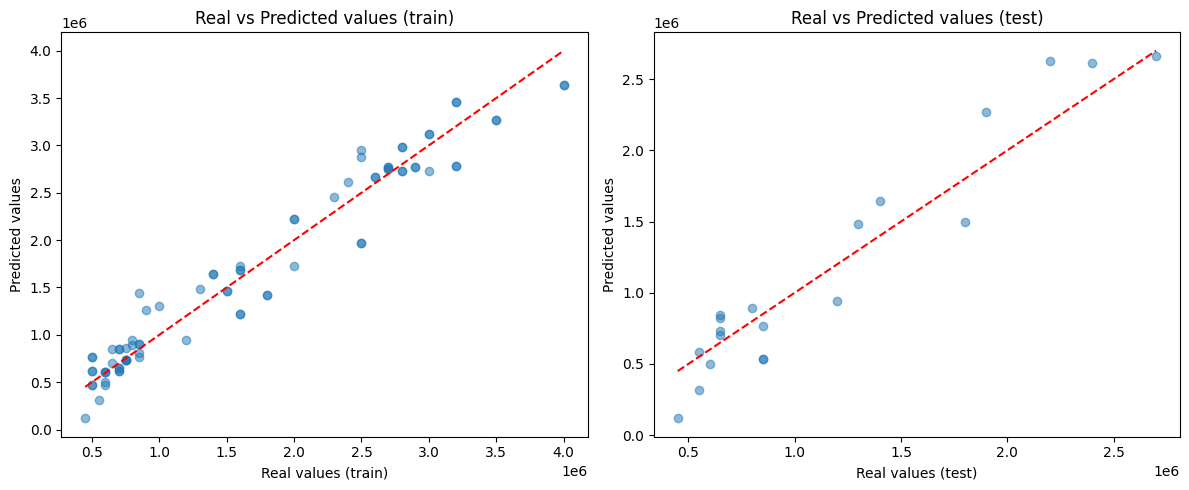

In [99]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

axes[0].scatter(y_train, prediction_4_train, alpha = 0.5)
axes[0].plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         'r--')
axes[0].set_xlabel("Real values (train)")
axes[0].set_ylabel("Predicted values")
axes[0].set_title("Real vs Predicted values (train)")

axes[1].scatter(y_test, prediction_4_test, alpha = 0.5)
axes[1].plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
axes[1].set_xlabel("Real values (test)")
axes[1].set_ylabel("Predicted values")
axes[1].set_title("Real vs Predicted values (test)")

plt.tight_layout()
plt.show();

However, we can see that the coefficient of determination has increased on the test data, and the error level has also decreased.

In [100]:
alpha = 0.25

significant_features_df_25 = summary_3.tables[1][summary_3.tables[1]['P>|t|'] <= alpha]
significant_features_25 = significant_features_df_25.index.tolist()
significant_features_25

['const',
 'Kilometers_Driven',
 'Mileage',
 'Power',
 'Fuel_Code',
 'Transmission_Code',
 'Audi',
 'BMW',
 'Ford',
 'Honda',
 'Hyundai',
 'Mahindra',
 'Maruti',
 'Mercedes',
 'Tata',
 'Volkswagen']

In [101]:
valid_features_train_25 = [i for i in significant_features_25 if i in scaled_train.columns]

signf_features_train_25 = scaled_train[valid_features_train_25]
signf_features_train_25 = sm.add_constant(signf_features_train_25)
signf_features_train_25.head()

,const,Kilometers_Driven,Mileage,Power,Fuel_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Volkswagen
83,1.0,-0.693871,0.274862,-0.231967,0.975305,0.795395,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,3.229330
55,1.0,-0.039533,-0.018324,0.247012,-1.025320,0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.309662
26,1.0,-0.039533,-0.604696,0.910213,0.975305,0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.309662
54,1.0,0.396692,0.274862,-0.784634,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,3.229330
19,1.0,-0.257646,-1.484254,0.910213,0.975305,0.795395,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,2.808717,-0.377964,-0.309662


In [102]:
valid_features_test_25 = [i for i in significant_features_25 if i in scaled_test.columns]

signf_features_test_25 = scaled_test[valid_features_test_25]
signf_features_test_25 = sm.add_constant(signf_features_test_25)
signf_features_test_25.head()

,const,Kilometers_Driven,Mileage,Power,Fuel_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Volkswagen
17,1.0,1.051030,-0.604696,-0.231967,0.975305,0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.309662
41,1.0,-0.257646,0.861234,-1.214487,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.258199,3.511885,-0.229416,-0.258199,-0.356034,-0.377964,-0.309662
92,1.0,0.396692,0.274862,-0.784634,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,3.229330
14,1.0,-1.130096,0.568048,-0.784634,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,3.872983,-0.356034,-0.377964,-0.309662
68,1.0,-0.257646,0.861234,-0.895168,0.975305,-1.257237,-0.333333,-0.356034,2.808717,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.309662


In [103]:
model_5 = sm.OLS(y_train, signf_features_train_25).fit()

In [104]:
print(model_5.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           4.85e-38
Time:                        02:17:16   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.65e+0

In [105]:
prediction_5_train = model_5.predict(signf_features_train_25)
prediction_5_test = model_5.predict(signf_features_test_25)

In [106]:
rmse_5_train = np.sqrt(mean_squared_error(y_train, prediction_5_train)).round(4)
rmse_5_test = np.sqrt(mean_squared_error(y_test, prediction_5_test)).round(4)

print("Train RMSE:", rmse_5_train)
print("Test RMSE:", rmse_5_test)

Train RMSE: 212184.2642
Test RMSE: 250977.9544


In [107]:
r2_5_train = round(r2_score(y_train, prediction_5_train), 4)
r2_5_test = round(r2_score(y_test, prediction_5_test), 4)

print("Train R^2:", r2_5_train)
print("Test R^2:", r2_5_test)

Train R^2: 0.9579
Test R^2: 0.8607


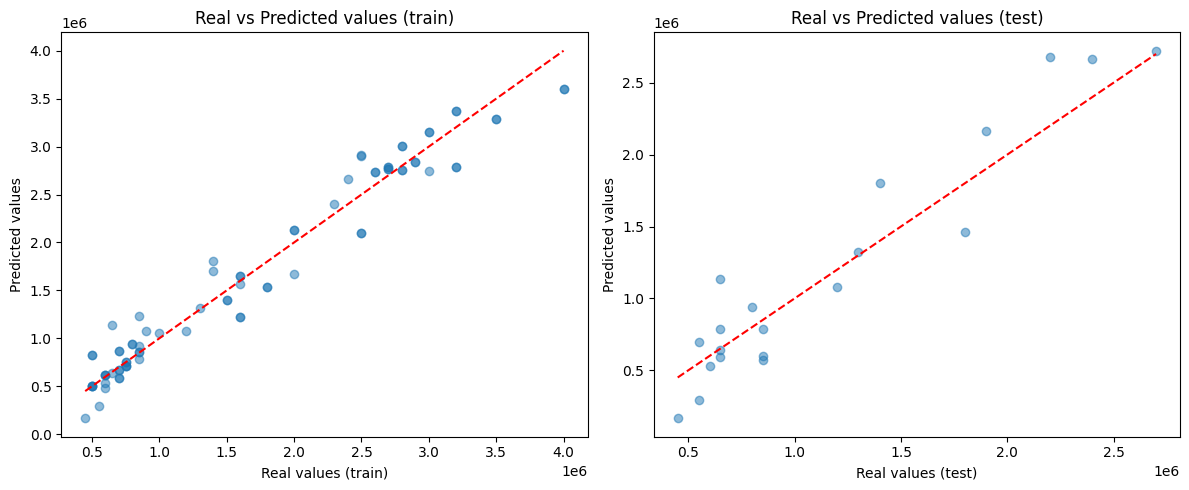

In [108]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

axes[0].scatter(y_train, prediction_5_train, alpha = 0.5)
axes[0].plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         'r--')
axes[0].set_xlabel("Real values (train)")
axes[0].set_ylabel("Predicted values")
axes[0].set_title("Real vs Predicted values (train)")

axes[1].scatter(y_test, prediction_5_test, alpha = 0.5)
axes[1].plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
axes[1].set_xlabel("Real values (test)")
axes[1].set_ylabel("Predicted values")
axes[1].set_title("Real vs Predicted values (test)")

plt.tight_layout()
plt.show();

As with the significance level of features 0.05, in this case the coefficient of determination decreased, namely by 0.01 to the level of 0.958, which means that 95.8% of the modeled data is described by the selected factors. At the same time, the adjusted coefficient of determination also decreased by 0.02.

According to AIC and BIC, this model fits the data better considering the number of features.


| Model  | Adequate (F-statistics) | All coefficients are statistically significant | R^2 train | Adjusted R^2 train | R^2 test| RMSE train | RMSE test |
|---------|-----|----|-------|-------|-------|-----------|----------------------------------------------------------------------|
| model_1 (2-3) | Yes | No | 0.959 | 0.946 | 0.851 | 210342.80 | 259601.26|
| model_4 | Yes | No | 0.951 | 0.943 | 0.8797 | 227824.30 | 233241.86 |
| model_5 | Yes | Yes | 0.958 | 0.948 | 0.8607 | 212184.26 | 250977.95 |

Given the obtained modeling results for further practical use and as a basis, I would recommend the extreme model model_5 from the 10th task, which is adequate, all coefficients are statistically significant, the level of the mean square error is acceptable for this case, and a significant amount of data is described by the selected factors.

Although model_4 from the 9th task has higher values ​​of the coefficient of determination for the test data set, and a lower error, I would not choose it in actual form for practical use at the moment, since there are still statistically insignificant factors. For this model, I would see how the results will change after removing the relevant features.

In addition, before making a final decision, it is necessary to check the model for the presence / absence of major statistical problems (multicollinearity and heteroscedasticity) in order to be sure that the obtained interpretation of the influence of factors and the predicted values ​​will be correct.

In [109]:
vif_df = pd.DataFrame({
    "feature": signf_features_train_25.columns,
    "VIF": [variance_inflation_factor(signf_features_train_25, i) for i in range(signf_features_train_25.shape[1])]
})

vif_df

,feature,VIF
0,const,1.000000
1,Kilometers_Driven,1.709269
2,Mileage,2.903321
3,Power,3.448202
4,Fuel_Code,1.404554
5,Transmission_Code,2.449286
6,Audi,2.117951
7,BMW,2.916866
8,Ford,2.273281
9,Honda,2.080383


Since VIF is less than 5 for all factors, multicollinearity is not observed.

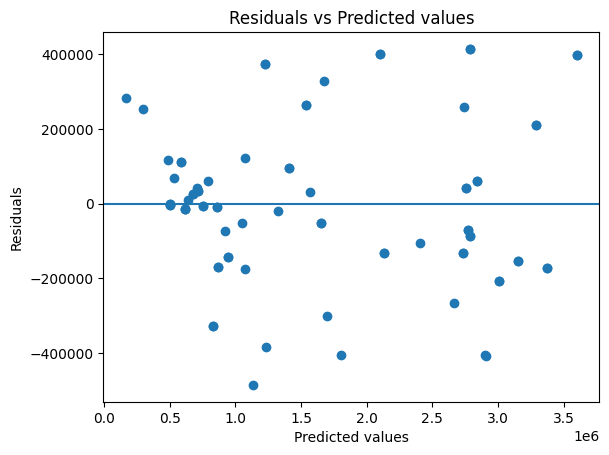

In [110]:
residuals = y_train - prediction_5_train

plt.scatter(prediction_5_train, residuals)
plt.axhline(0)
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted values")
plt.show();

In [111]:
bp_LM_statistic, bp_LM_p_value, bp_F_statistic, bp_F_p_value = het_breuschpagan(residuals, signf_features_train_25)

if bp_F_p_value < 0.05:
    print("Гетероскедастичність")
else:
    print("Гомоскедастичність")

Гетероскедастичність


In [112]:
wh_LM_statistic, wh_LM_p_value, wh_F_statistic, wh_F_p_value = het_white(residuals, signf_features_train_25)

if wh_F_p_value < 0.05:
    print("Гетероскедастичність")
else:
    print("Гомоскедастичність")

Гетероскедастичність


In [113]:
gd_test = het_goldfeldquandt(y_train, signf_features_train_25, alternative = "two-sided")

if gd_test[1] < 0.05:
    print("Гетероскедастичність")
else:
    print("Гомоскедастичність")

Гомоскедастичність


According to the scatter plot of the predicted values ​​and residuals, we observe a cloud-like spread of the data, indicating homoscedasticity. This fact is also confirmed by the Goldfeld-Quandt test.
At the same time, the White and Broisch-Pagan tests indicate, most likely, weak heteroscedasticity.

However, since its signs are not clearly expressed, we can assume that heteroscedasticity is absent, and we can trust our standard errors and confidence intervals as necessary.

So, for practical use, I recommend choosing model 5 from task 10.